# Regression  LAB Session

In [1]:
import os
os.environ["PYSPARK_PYTHON"] = "python"
from pyspark.sql import *
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, FloatType
from pyspark.sql.functions import *
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

In [2]:
spark = SparkSession.builder.appName("House_Pricing_Prediction").master("local[*]").getOrCreate()

In [3]:
import pandas as pd

### load data from sklearn

In [4]:
from sklearn.datasets import fetch_california_housing

In [5]:
housing = fetch_california_housing()

In [6]:
df_pandas = pd.DataFrame(housing.data, columns=housing.feature_names)
df_pandas['MedHouseVal'] = housing.target
df_pandas

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [7]:
df = spark.createDataFrame(df_pandas)
df.show(5)

+------+--------+------------------+------------------+----------+------------------+--------+---------+-----------+
|MedInc|HouseAge|          AveRooms|         AveBedrms|Population|          AveOccup|Latitude|Longitude|MedHouseVal|
+------+--------+------------------+------------------+----------+------------------+--------+---------+-----------+
|8.3252|    41.0| 6.984126984126984|1.0238095238095237|     322.0|2.5555555555555554|   37.88|  -122.23|      4.526|
|8.3014|    21.0| 6.238137082601054|0.9718804920913884|    2401.0| 2.109841827768014|   37.86|  -122.22|      3.585|
|7.2574|    52.0| 8.288135593220339| 1.073446327683616|     496.0|2.8022598870056497|   37.85|  -122.24|      3.521|
|5.6431|    52.0|5.8173515981735155|1.0730593607305936|     558.0| 2.547945205479452|   37.85|  -122.25|      3.413|
|3.8462|    52.0| 6.281853281853282|1.0810810810810811|     565.0|2.1814671814671813|   37.85|  -122.25|      3.422|
+------+--------+------------------+------------------+---------

In [8]:
print("Number of rows: ", df.count())
print("Number of columns: ", len(df.columns))

Number of rows:  20640
Number of columns:  9


### Check for null and dublicates 
distinct and number of rows should vary if the they have dublicates

In [9]:
df.distinct().count()
df_clean = df.distinct()

In [10]:
df.printSchema()

root
 |-- MedInc: double (nullable = true)
 |-- HouseAge: double (nullable = true)
 |-- AveRooms: double (nullable = true)
 |-- AveBedrms: double (nullable = true)
 |-- Population: double (nullable = true)
 |-- AveOccup: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- MedHouseVal: double (nullable = true)



### Feature Engineering
Lecturer takes directly the features but in our case we have to find correlation or use any way to determine the best features

In [11]:
df_features = df_clean.withColumn(
    "RoomPerHousehold", col("AveRooms") / col("AveBedrms")
).withColumn(
    "PopulationPerHousehold", col("Population") / col("AveOccup")
)

df_features.printSchema()

root
 |-- MedInc: double (nullable = true)
 |-- HouseAge: double (nullable = true)
 |-- AveRooms: double (nullable = true)
 |-- AveBedrms: double (nullable = true)
 |-- Population: double (nullable = true)
 |-- AveOccup: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- MedHouseVal: double (nullable = true)
 |-- RoomPerHousehold: double (nullable = true)
 |-- PopulationPerHousehold: double (nullable = true)



In [12]:
feature_cols = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude", "RoomPerHousehold", "PopulationPerHousehold"]

target_col = "MedHouseVal"

In [13]:
from pyspark.ml.feature import VectorAssembler


In [14]:
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
# above code is used to create a new column called "features" which is a vector of all the feature columns. This is required for the machine learning algorithms in Spark which expect the features to be in a single vector column.
df_assembled = assembler.transform(df_features)
df_assembled.show(5)

+------+--------+------------------+------------------+----------+------------------+--------+---------+-----------+------------------+----------------------+--------------------+
|MedInc|HouseAge|          AveRooms|         AveBedrms|Population|          AveOccup|Latitude|Longitude|MedHouseVal|  RoomPerHousehold|PopulationPerHousehold|            features|
+------+--------+------------------+------------------+----------+------------------+--------+---------+-----------+------------------+----------------------+--------------------+
|2.4038|    41.0| 4.495798319327731|1.0336134453781514|     317.0|2.6638655462184873|   37.85|  -122.28|      1.075| 4.349593495934959|                 119.0|[2.4038,41.0,4.49...|
|1.7348|    43.0|3.9802371541501977| 1.233201581027668|     558.0| 2.205533596837945|   37.82|  -122.27|      1.375|3.2275641025641026|    252.99999999999997|[1.7348,43.0,3.98...|
|1.9028|    51.0|4.0561224489795915|1.0561224489795917|     949.0| 2.420918367346939|    37.8|  -122

In [15]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withMean=True, withStd=True)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)

In [16]:
train_df ,test_df = df_scaled.randomSplit([0.8, 0.2], seed=42)

In [17]:
train_df.count()

16560

In [18]:
lr = LinearRegression(featuresCol="scaledFeatures", labelCol=target_col, maxIter=100, regParam=0.01)
lr_model = lr.fit(train_df)
lr_model.intercept

2.0694427043315198

In [19]:
# Slope = coefficients
coefficients = lr_model.coefficients
for i in range(len(feature_cols)):
    feature = feature_cols[i]
    coeff = coefficients[i]
    print(feature + ": " + str(coeff))

MedInc: 0.8528782026322533
HouseAge: 0.15076568137895077
AveRooms: 0.1738795967025858
AveBedrms: -0.09034084316194081
Population: -0.3996773617500354
AveOccup: -0.0005009738414267039
Latitude: -0.7676491854027516
Longitude: -0.7244544789339058
RoomPerHousehold: -0.2440429633976589
PopulationPerHousehold: 0.4489209123963679


In [20]:
lr_predictions = lr_model.transform(test_df)
lr_predictions.printSchema()

root
 |-- MedInc: double (nullable = true)
 |-- HouseAge: double (nullable = true)
 |-- AveRooms: double (nullable = true)
 |-- AveBedrms: double (nullable = true)
 |-- Population: double (nullable = true)
 |-- AveOccup: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- MedHouseVal: double (nullable = true)
 |-- RoomPerHousehold: double (nullable = true)
 |-- PopulationPerHousehold: double (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)
 |-- prediction: double (nullable = false)



In [21]:
lr_predictions.select("prediction").show(5)

+-------------------+
|         prediction|
+-------------------+
| 0.6648682253414737|
| 0.8896051628491888|
| 1.1357381071441381|
|0.49113994668035565|
| 0.9331499479322534|
+-------------------+
only showing top 5 rows



In [22]:
lr_with_error = lr_predictions.withColumn("Error", col(target_col) - col("prediction"))

In [23]:
lr_with_error.printSchema()

root
 |-- MedInc: double (nullable = true)
 |-- HouseAge: double (nullable = true)
 |-- AveRooms: double (nullable = true)
 |-- AveBedrms: double (nullable = true)
 |-- Population: double (nullable = true)
 |-- AveOccup: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- MedHouseVal: double (nullable = true)
 |-- RoomPerHousehold: double (nullable = true)
 |-- PopulationPerHousehold: double (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)
 |-- prediction: double (nullable = false)
 |-- Error: double (nullable = true)



In [24]:
lr_with_error.select(
    col(target_col).alias("Actual Price"),
    col("prediction").alias("Predicted Price"),
    col("Error").alias("Residuals")
).show(10)

+------------+-------------------+--------------------+
|Actual Price|    Predicted Price|           Residuals|
+------------+-------------------+--------------------+
|       0.735| 0.6648682253414737| 0.07013177465852627|
|       1.625| 0.8896051628491888|  0.7353948371508112|
|       0.675| 1.1357381071441381| -0.4607381071441381|
|       1.625|0.49113994668035565|  1.1338600533196443|
|       0.875| 0.9331499479322534|-0.05814994793225...|
|       1.113| 0.7276692982496178|  0.3853307017503822|
|       1.344| 0.9888095412741051| 0.35519045872589494|
|       1.042| 0.9057365015068712|  0.1362634984931288|
|       0.818| 1.0195557534607844|-0.20155575346078447|
|       1.531| 0.5739967159083941|  0.9570032840916058|
+------------+-------------------+--------------------+
only showing top 10 rows



In [25]:
evaluator_r2 = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="r2")
# metric name  =  rmse,mae,r2 : according to the metric name, the evaluation will be done. Here we are using r2 which is the coefficient of determination. It is a measure of how well the regression model fits the data. The value of r2 ranges from 0 to 1, where 1 indicates a perfect fit and 0 indicates that the model does not explain any of the variability in the target variable.
# calculate rmse, mae yourself
lm_r2 = evaluator_r2.evaluate(lr_predictions)
print("R2: ", lm_r2)

R2:  0.6454736092562393


In [27]:
import matplotlib.pyplot as plt

lr_pred_pandas = lr_predictions.select(col(target_col).alias("Actual"),col("prediction").alias("Predicted")).toPandas()

lr_pred_pandas

,Actual,Predicted
0,0.73500,0.664868
1,1.62500,0.889605
2,0.67500,1.135738
3,1.62500,0.491140
4,0.87500,0.933150
...,...,...
4075,5.00001,6.832841
4076,5.00001,6.631838
4077,1.31300,7.237605
4078,5.00001,6.937296


In [28]:
lr_pred_pandas.head()

,Actual,Predicted
0,0.735,0.664868
1,1.625,0.889605
2,0.675,1.135738
3,1.625,0.491140
4,0.875,0.933150


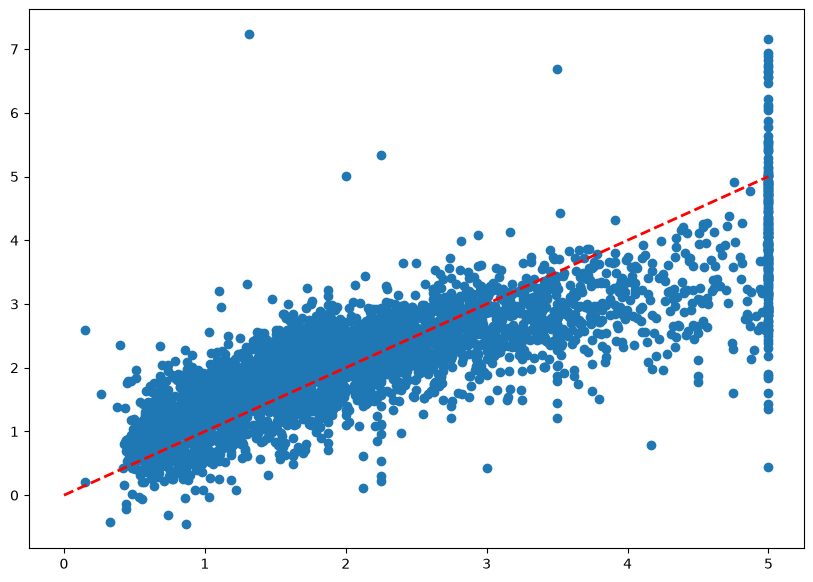

In [29]:
fix ,ax = plt.subplots(figsize=(10, 7))
ax.scatter(lr_pred_pandas["Actual"], lr_pred_pandas["Predicted"])
ax.plot([0,5], [0,5], "r--", lw = 2)
plt.show()

# Implement Random Forest Regressor